In [ ]:
import pandas as pd
import os
os.chdir("/Users/thomasmaisch/Desktop/Alles/BGG_Project/bgg-data-analysis")

In [ ]:
df = pd.read_csv('boardgames_ranks.csv')
df_filtered = df[df['is_expansion'] == 0]
df_filtered = df_filtered.sort_values('usersrated', ascending=False)
df_top5000 = df_filtered.head(5000)

print(df_top5000.shape)
print(df_top5000[['id', 'name', 'usersrated', 'rank']].head(10))

In [ ]:
df_top5000.to_csv("top5000_games.csv", index=False)

In [15]:
import requests
import time
from dotenv import load_dotenv
import os
import xml.etree.ElementTree as ET

load_dotenv()
token = os.getenv("BGG_TOKEN")
headers = {"Authorization": f"Bearer {token}"}

def parse_block(xml_text):
    root = ET.fromstring(xml_text)
    games = []
    for item in root.findall("item"):
        game = {}
        game["id"] = item.get("id")
        game["name"] = item.find("name[@type='primary']").get("value")
        game["yearpublished"] = item.findtext("yearpublished")
        game["minplayers"] = item.find("minplayers").get("value")
        game["maxplayers"] = item.find("maxplayers").get("value")
        game["minplaytime"] = item.find("minplaytime").get("value")
        game["maxplaytime"] = item.find("maxplaytime").get("value")
        game["minage"] = item.find("minage").get("value")
        stats = item.find("statistics/ratings")
        game["usersrated"] = stats.find("usersrated").get("value")
        game["average"] = stats.find("average").get("value")
        game["bayesaverage"] = stats.find("bayesaverage").get("value")
        game["complexity"] = stats.find("averageweight").get("value")
        games.append(game)
    return games

ids = df_top5000["id"].astype(str).tolist()
blocks = [ids[i:i+20] for i in range(0, len(ids), 20)]

all_games = []
for i, block in enumerate(blocks):
    url = f"https://boardgamegeek.com/xmlapi2/thing?id={','.join(block)}&type=boardgame&stats=1"
    response = requests.get(url, headers=headers)
    
    if response.status_code == 200:
        games = parse_block(response.text)
        all_games.extend(games)
        print(f"Block {i+1}/{len(blocks)} ✓ ({len(all_games)} Spiele)")
    else:
        print(f"Block {i+1} Fehler: {response.status_code}")
    
    time.sleep(3)

df_games = pd.DataFrame(all_games)
df_games.to_csv("bgg_raw_data.csv", index=False)
print("Fertig!")


Block 61/250 ✓ (1220 Spiele)
Block 62/250 ✓ (1240 Spiele)
Block 63/250 ✓ (1260 Spiele)
Block 64/250 ✓ (1280 Spiele)
Block 65/250 ✓ (1300 Spiele)
Block 66/250 ✓ (1320 Spiele)
Block 67/250 ✓ (1340 Spiele)
Block 68/250 ✓ (1360 Spiele)
Block 69/250 ✓ (1380 Spiele)
Block 70/250 ✓ (1400 Spiele)
Block 71/250 ✓ (1420 Spiele)
Block 72/250 ✓ (1440 Spiele)
Block 73/250 ✓ (1460 Spiele)
Block 74/250 ✓ (1480 Spiele)
Block 75/250 ✓ (1500 Spiele)
Block 76/250 ✓ (1520 Spiele)
Block 77/250 ✓ (1540 Spiele)
Block 78/250 ✓ (1560 Spiele)
Block 79/250 ✓ (1580 Spiele)
Block 80/250 ✓ (1600 Spiele)
Block 81/250 ✓ (1620 Spiele)
Block 82/250 ✓ (1640 Spiele)
Block 83/250 ✓ (1660 Spiele)
Block 84/250 ✓ (1680 Spiele)
Block 85/250 ✓ (1700 Spiele)
Block 86/250 ✓ (1720 Spiele)
Block 87/250 ✓ (1740 Spiele)
Block 88/250 ✓ (1760 Spiele)
Block 89/250 ✓ (1780 Spiele)
Block 90/250 ✓ (1800 Spiele)
Block 91/250 ✓ (1820 Spiele)
Block 92/250 ✓ (1840 Spiele)
Block 93/250 ✓ (1860 Spiele)
Block 94/250 ✓ (1880 Spiele)
Block 95/250 ✓

In [16]:
print(df_games.head())
print(df_games.shape)

       id               name yearpublished minplayers maxplayers minplaytime  \
0      13              Catan                        3          4          60   
1     822        Carcassonne                        2          5          30   
2   30549           Pandemic                        2          4          45   
3  167791  Terraforming Mars                        1          5         120   
4  266192           Wingspan                        1          5          40   

  maxplaytime minage usersrated  average bayesaverage complexity  
0         120     10     142781   7.0904      6.90249     2.2816  
1          45      7     140178   7.4166      7.29878     1.8846  
2          45      8     135383  7.51287      7.40339     2.3939  
3         120     12     113682  8.33408      8.18309     3.2728  
4          70     10     113544  7.99763      7.84451      2.481  
(5000, 12)


In [17]:
df_games.to_csv("bgg_raw_data.csv", index=False)

In [21]:
df_games.isna().mean()
df_games.head()

,id,name,yearpublished,minplayers,maxplayers,minplaytime,maxplaytime,minage,usersrated,average,bayesaverage,complexity
0,13,Catan,,3,4,60,120,10,142781,7.0904,6.90249,2.2816
1,822,Carcassonne,,2,5,30,45,7,140178,7.4166,7.29878,1.8846
2,30549,Pandemic,,2,4,45,45,8,135383,7.51287,7.40339,2.3939
3,167791,Terraforming Mars,,1,5,120,120,12,113682,8.33408,8.18309,3.2728
4,266192,Wingspan,,1,5,40,70,10,113544,7.99763,7.84451,2.481


In [22]:
df_games.isna().mean()

id               0.0
name             0.0
yearpublished    0.0
minplayers       0.0
maxplayers       0.0
minplaytime      0.0
maxplaytime      0.0
minage           0.0
usersrated       0.0
average          0.0
bayesaverage     0.0
complexity       0.0
dtype: float64

In [23]:
print(df_games["yearpublished"].unique()[:20])

<StringArray>
['']
Length: 1, dtype: str


In [24]:
import numpy as np

df_games = df_games.replace("", np.nan)

print(df_games.isna().mean())

id               0.0
name             0.0
yearpublished    1.0
minplayers       0.0
maxplayers       0.0
minplaytime      0.0
maxplaytime      0.0
minage           0.0
usersrated       0.0
average          0.0
bayesaverage     0.0
complexity       0.0
dtype: float64


In [ ]:
df_top5000["id"] = df_top5000["id"].astype(str)
df_games = df_games.drop(columns=['yearpublished'])
df_games = df_games.merge(df_top5000[["id", "yearpublished"]], on="id", how="left")
df_games.head()

,id,name,minplayers,maxplayers,minplaytime,maxplaytime,minage,usersrated,average,bayesaverage,complexity,yearpublished
0,13,Catan,3,4,60,120,10,142781,7.0904,6.90249,2.2816,1995
1,822,Carcassonne,2,5,30,45,7,140178,7.4166,7.29878,1.8846,2000
2,30549,Pandemic,2,4,45,45,8,135383,7.51287,7.40339,2.3939,2008
3,167791,Terraforming Mars,1,5,120,120,12,113682,8.33408,8.18309,3.2728,2016
4,266192,Wingspan,1,5,40,70,10,113544,7.99763,7.84451,2.481,2019


In [32]:
df_games.to_csv("bgg_raw_data.csv", index=False)

In [37]:
num_cols = ['minplayers', 'maxplayers', 'minplaytime', 'maxplaytime', 'minage', 'usersrated', 'average', 'bayesaverage', 'complexity']

df_games[num_cols] = df_games[num_cols].astype(float)

print(df_games.describe())

        minplayers  maxplayers  minplaytime  maxplaytime       minage  \
count  5000.000000  5000.00000  5000.000000   5000.00000  5000.000000   
mean      1.862000     5.47900    50.582200     76.36960    10.732400   
std       0.715163     8.08667    44.861031    206.40876     2.681684   
min       0.000000     0.00000     0.000000      0.00000     0.000000   
25%       1.000000     4.00000    30.000000     30.00000     8.000000   
50%       2.000000     4.00000    40.000000     60.00000    10.000000   
75%       2.000000     6.00000    60.000000     90.00000    13.000000   
max       8.000000   100.00000   720.000000  12000.00000    21.000000   

          usersrated      average  bayesaverage   complexity  yearpublished  
count    5000.000000  5000.000000   5000.000000  5000.000000     5000.00000  
mean     5079.884400     6.983714      6.262329     2.238500     2000.93340  
std      9770.501732     0.693650      0.533913     0.802301      180.17408  
min       818.000000     2.422

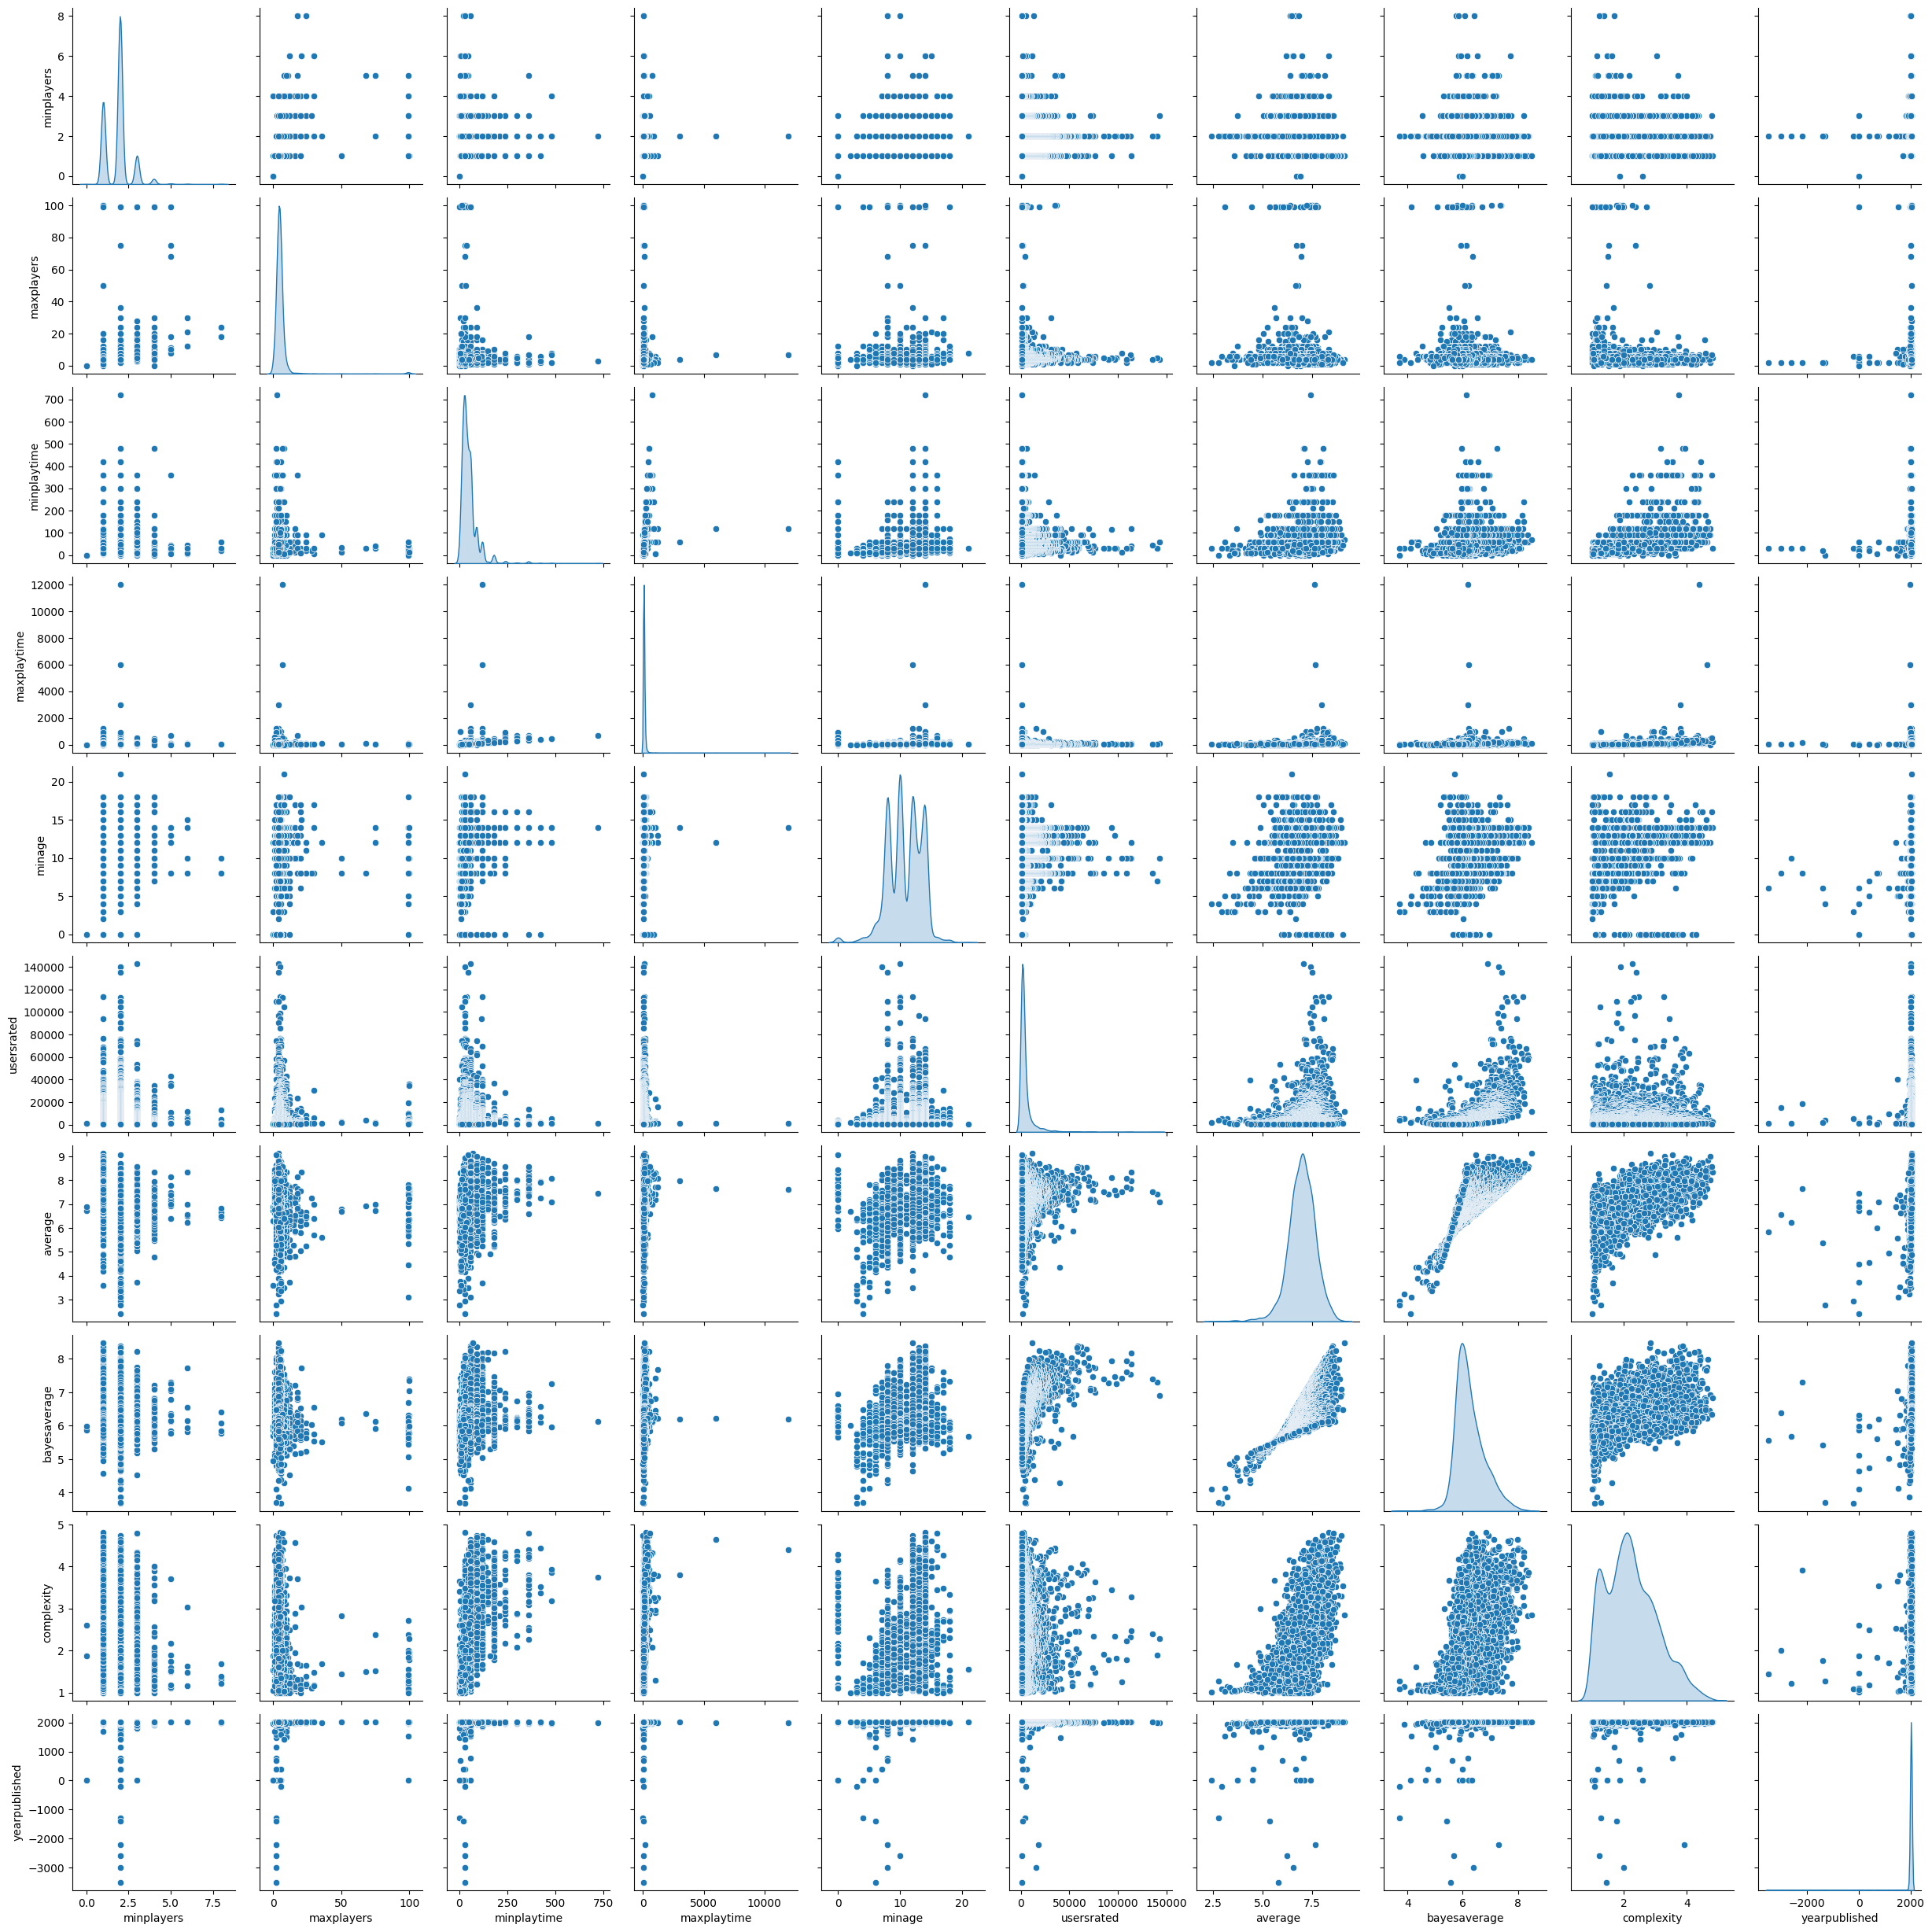

In [43]:
import seaborn as sns

sns.pairplot(df_games, diag_kind='kde')

In [45]:
print('minplayers == 0:', (df_games['minplayers'] == 0).sum())
print('minplayers > 6:', (df_games['minplayers'] > 6).sum())
print('maxplayers == 0:', (df_games['maxplayers'] == 0).sum())
print('maxplayers > 20:', (df_games['maxplayers'] > 20).sum())
print('minplaytime == 0:', (df_games['minplaytime'] == 0).sum())
print('maxplaytime > 600:', (df_games['maxplaytime'] > 600).sum())
print('yearpublished < 1800:', (df_games['yearpublished'] < 1800).sum())
print('yearpublished > 2026:', (df_games['yearpublished'] > 2026).sum())

minplayers == 0: 2
minplayers > 6: 4
maxplayers == 0: 4
maxplayers > 20: 48
minplaytime == 0: 7
maxplaytime > 600: 15
yearpublished < 1800: 32
yearpublished > 2026: 1


In [49]:
print(df_games[df_games['minplaytime'] == 0][['name', 'minplaytime', 'maxplaytime']])
print(df_games[df_games['maxplaytime'] > 6000][['name', 'minplaytime', 'maxplaytime']])
print(df_games[df_games['yearpublished'] < 1800][['name', 'yearpublished']])
print(df_games[df_games['yearpublished'] > 2026][['name', 'yearpublished']])

                                      name  minplaytime  maxplaytime
71                                   Chess          0.0          0.0
1495                            BattleTech          0.0          0.0
1664                        Disney Lorcana          0.0          0.0
2468                        Don't Get Got!          0.0          0.0
3500                 Unpublished Prototype          0.0          0.0
3521                Traditional Card Games          0.0          0.0
4430  Dungeons & Dragons: Adventure Begins          0.0          0.0
                 name  minplaytime  maxplaytime
3462  Empires in Arms        120.0      12000.0
                        name  yearpublished
71                     Chess           1475
272                       Go          -2200
349               Backgammon          -3000
494                 Cribbage           1630
569                 Checkers           1150
683                 Dominoes           1500
901                  Pachisi            400


In [58]:
print(len(df_games[df_games['yearpublished'] < 1900][['name', 'yearpublished', 'bayesaverage', 'usersrated']]))

47


In [59]:
print((df_games['yearpublished'] == 0).sum())
print(df_games[df_games['yearpublished'] == 0][['name', 'yearpublished']].head(10))

7
                        name  yearpublished
2409                 Go Fish              0
2518                  Carrom              0
2699                     War              0
2886        Eat Poop You Cat              0
3481            Crazy Eights              0
3500   Unpublished Prototype              0
3521  Traditional Card Games              0
